<a href="https://colab.research.google.com/github/Yeonjicording/pinn3_0416/blob/main/_workspace/experiment_code/colab_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inverse-PINN for Scout Odometry Correction

Colab end-to-end notebook.

Pipeline: upload 2 CSVs (GT + Odom) -> align/split -> build model + physics loss -> train -> plot -> test eval.

Requires `data_module.py`, `model_module.py`, `train_module.py` alongside this notebook (see Cell 2).

## Cell 1: Environment check + minimal installs

In [9]:
import sys, platform
print('python:', sys.version.split()[0], '|', platform.platform())

# torch / numpy / pandas usually pre-installed on Colab; install only if missing.
try:
    import torch, numpy as np, pandas as pd, matplotlib  # noqa: F401
    print('torch :', torch.__version__, '| CUDA:', torch.cuda.is_available(),
          '| device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
    print('numpy :', np.__version__)
    print('pandas:', pd.__version__)
except Exception as e:
    print('Installing missing deps:', e)
    !pip install -q torch numpy pandas matplotlib

python: 3.12.13 | Linux-6.6.113+-x86_64-with-glibc2.35
torch : 2.10.0+cpu | CUDA: False | device: CPU
numpy : 2.0.2
pandas: 2.2.2


## Cell 2: Import the 3 .py modules

Choose ONE of the two options below (keep the other commented).

- **Option A**: mount Google Drive and point to the folder containing the .py files.
- **Option B**: use `files.upload()` to upload the three files from your local machine.

In [21]:
import os, sys, importlib

# =====================================================================
# Option A: Google Drive mount
# ---------------------------------------------------------------------
# from google.colab import drive
# drive.mount('/content/drive')
# CODE_DIR = '/content/drive/MyDrive/AIR_Labs/2026/클로드실험/experiment_code'
# sys.path.insert(0, CODE_DIR)

# =====================================================================
# Option B: files.upload() — upload data_module.py, model_module.py, train_module.py
# ---------------------------------------------------------------------
from google.colab import files  # type: ignore
print('Upload: data_module.py, model_module.py, train_module.py')
uploaded = files.upload()
CODE_DIR = '/content'
for name, payload in uploaded.items():
    with open(os.path.join(CODE_DIR, name), 'wb') as f:
        f.write(payload)
sys.path.insert(0, CODE_DIR)

# =====================================================================
# Import
import data_module, model_module, train_module
for m in (data_module, model_module, train_module):
    importlib.reload(m)
print('Loaded:', data_module.__name__, model_module.__name__, train_module.__name__)

Upload: data_module.py, model_module.py, train_module.py


Saving train_module.py to train_module (1).py
Saving model_module.py to model_module (1).py
Saving data_module.py to data_module (1).py
Loaded: data_module model_module train_module


## Cell 3: Upload the two CSV files (GT + Odom)

In [22]:
from data_module import upload_data_colab
GT_PATH, ODOM_PATH = upload_data_colab(gt_hint='gt', odom_hint='odom', save_dir='/content')
print('GT  :', GT_PATH)
print('Odom:', ODOM_PATH)

Please upload 2 CSV files: Ground Truth and Odometry.


Saving odom.csv to odom (1).csv
Saving gt.csv to gt (1).csv
GT   : /content/gt (1).csv
Odom : /content/odom (1).csv
GT  : /content/gt (1).csv
Odom: /content/odom (1).csv


In [23]:
import data_module
print(data_module.__file__)

with open(data_module.__file__, "r") as f:
    text = f.read()

print("_read_gt_csv" in text)
print("_absolute_xyz_to_delta_pose" in text)
print("GT_ABS_COLS" in text)

/content/data_module.py
True
True
True


## Cell 4: Align, split, fit scaler, build dataloaders + stationary ratio

In [24]:
from data_module import (load_and_align, split_timeseries, fit_scaler,
                          build_dataloaders, INPUT_COLS, detect_stationary)

BATCH_SIZE = 64

df = load_and_align(GT_PATH, ODOM_PATH, method='nearest')
print('aligned rows:', len(df))

df_tr, df_va, df_te = split_timeseries(df, ratios=(0.7, 0.15, 0.15))
print(f'split  train={len(df_tr)}  val={len(df_va)}  test={len(df_te)}')

scaler = fit_scaler(df_tr, [f'od_{c}' for c in INPUT_COLS])
loaders = build_dataloaders(df_tr, df_va, df_te, scaler,
                            batch_size=BATCH_SIZE, num_workers=0,
                            shuffle_train=False)

# overall stationary ratio (odom side) on the full aligned df for reporting
_ = detect_stationary(df, thresh_trans=1e-4, thresh_ang=1e-4)

aligned rows: 4151
split  train=2905  val=622  test=624
[stationary] ratio=26.85% (n=780/2905)
[stationary] ratio=0.00% (n=0/622)
[stationary] ratio=83.01% (n=518/624)
[stationary] ratio=31.27% (n=1298/4151)


## Cell 5: Build model + physics loss + smoke forward pass

In [25]:
import torch
from model_module import build_model, build_loss
from train_module import compute_data_weights, TrainConfig, set_seed

set_seed(42)

w_x, w_yaw = compute_data_weights(df_tr)
print(f'data_weights: w_x={w_x:.3e}  w_yaw={w_yaw:.3e}')

model = build_model({'name': 'pinn',
                     'model': {'hidden_dim': 128, 'hidden_blocks': 3, 'dropout': 0.1}})
loss_fn = build_loss({'loss': {
    'w_data': 1.0, 'w_stationary': 1.0, 'w_nonholonomic': 0.1,
    'w_coeff': 0.01, 'w_magnitude': 1e-3,
    'data_weights': (w_x, w_yaw),
}})

n_params = sum(p.numel() for p in model.parameters())
print(f'model params: {n_params:,}')
print('init coeffs:', model.coefficient_values())

# smoke forward
batch = next(iter(loaders['train']))
with torch.no_grad():
    pred = model(batch['x'])
    total, parts = loss_fn(pred, batch['y'], batch['x_raw'],
                            stationary=batch['stationary'], coeffs=model.coefficients())
print('pred shape:', tuple(pred.shape), '| parts:', {k: float(v) for k, v in parts.items()})

data_weights: w_x=2.383e+01  w_yaw=2.302e+00
model params: 50,693
init coeffs: {'b': 0.49000000953674316, 's_r': 1.0, 'alpha_sum': 2.0}
pred shape: (64, 2) | parts: {'total': 0.6316422820091248, 'data': 0.6313319206237793, 'stationary': 0.0002820219669956714, 'nonholonomic': 0.0002820219669956714, 'coeff': 0.0, 'magnitude': 0.00014101099804975092}


## Cell 6: Train (AdamW + Cosine + early stopping)

In [26]:
from train_module import train_api

SAVE_DIR = '/content/runs/pinn'

cfg = TrainConfig(
    epochs=300,
    mlp_lr=1e-3,
    coeff_lr_mult=0.3,
    weight_decay=1e-4,
    grad_clip_max_norm=1.0,
    scheduler='cosine',
    early_stop_patience=20,
    seed=42,
    device='auto',
    amp=True,
    deterministic=True,
    log_every=10,
    run_name='pinn_colab',
)

result = train_api(model, loss_fn, loaders['train'], loaders['val'], cfg, save_dir=SAVE_DIR)
print('best_path :', result['best_path'])
print('best_epoch:', result['history'].get('best_epoch'))
print('best_val  :', result['history'].get('best_val_data'))
print('final_coef:', result['history'].get('final_coefficients'))

[train] device=cpu amp=False epochs=300 seed=42 run=pinn_colab
[train] out_dir=/content/runs/pinn
[epoch    1/300] tr_total=2.6290e+00 tr_data=2.6182e+00 va_data=1.1958e+00 tr_stat=9.026e-04 tr_nh=9.895e-02 lr=1.00e-03 | b=0.489 sr=1.005 asum=2.002 *
[epoch    2/300] tr_total=8.5138e-01 tr_data=8.4047e-01 va_data=1.8335e-01 tr_stat=2.963e-03 tr_nh=7.900e-02 lr=1.00e-03 | b=0.489 sr=1.011 asum=2.001 *
[epoch    4/300] tr_total=7.4836e-01 tr_data=7.3733e-01 va_data=1.7703e-01 tr_stat=8.271e-04 tr_nh=1.014e-01 lr=1.00e-03 | b=0.489 sr=1.019 asum=2.001 *
[epoch   10/300] tr_total=6.2572e-01 tr_data=6.1051e-01 va_data=1.7386e-01 tr_stat=3.803e-03 tr_nh=1.133e-01 lr=9.97e-04 | b=0.489 sr=1.039 asum=2.002 *
[epoch   14/300] tr_total=6.1316e-01 tr_data=5.9827e-01 va_data=1.4876e-01 tr_stat=3.124e-03 tr_nh=1.168e-01 lr=9.95e-04 | b=0.488 sr=1.045 asum=2.002 *
[epoch   18/300] tr_total=5.9028e-01 tr_data=5.7571e-01 va_data=1.3583e-01 tr_stat=2.239e-03 tr_nh=1.224e-01 lr=9.91e-04 | b=0.488 sr=1.0

## Cell 7: Loss curves + coefficient trajectory

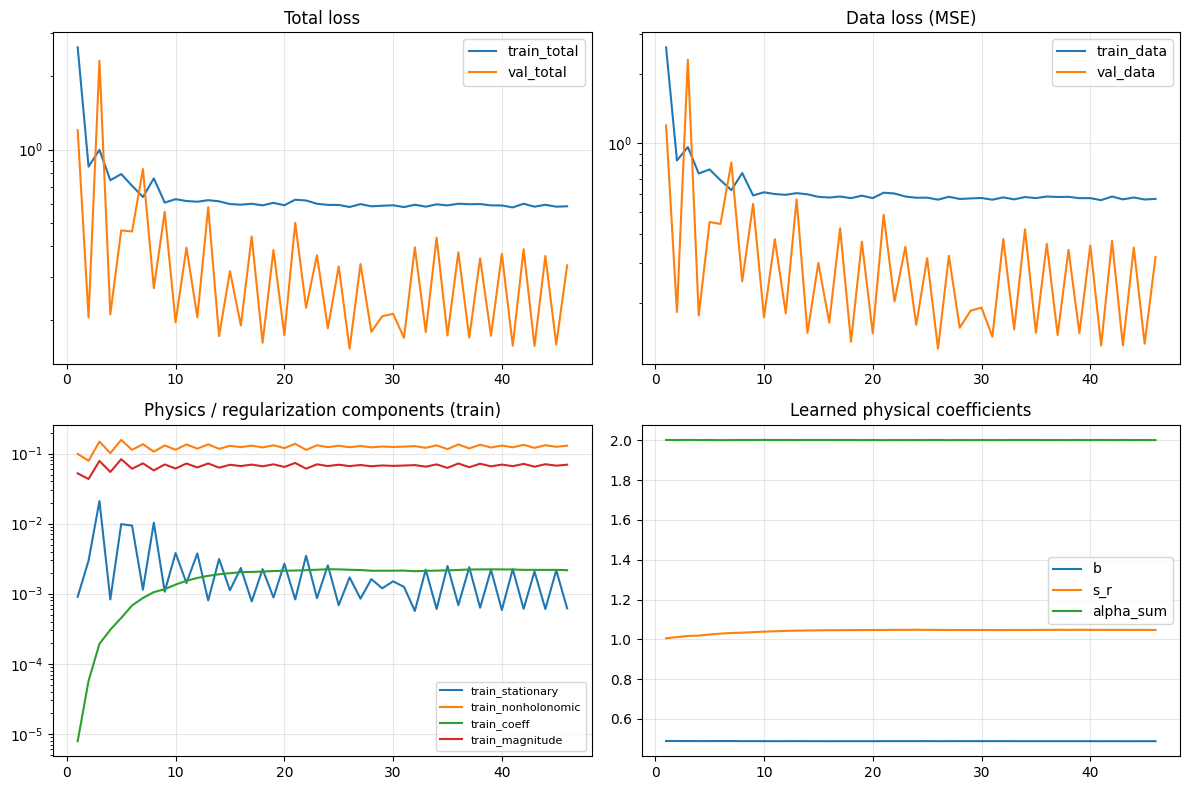

final coefficients: {'b': 0.4884292483329773, 's_r': 1.0470374822616577, 'alpha_sum': 2.001112937927246}


In [27]:
import json
import matplotlib.pyplot as plt

with open(f'{SAVE_DIR}/history.json', 'r') as f:
    hist = json.load(f)

rows = hist['epochs']
ep = [r['epoch'] for r in rows]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ax = axes[0, 0]
ax.plot(ep, [r['train_total'] for r in rows], label='train_total')
ax.plot(ep, [r['val_total'] for r in rows], label='val_total')
ax.set_title('Total loss'); ax.set_yscale('log'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(ep, [r['train_data'] for r in rows], label='train_data')
ax.plot(ep, [r['val_data'] for r in rows], label='val_data')
ax.set_title('Data loss (MSE)'); ax.set_yscale('log'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
for k in ('train_stationary', 'train_nonholonomic', 'train_coeff', 'train_magnitude'):
    ax.plot(ep, [r[k] for r in rows], label=k)
ax.set_title('Physics / regularization components (train)')
ax.set_yscale('log'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 1]
coefs = hist['coefficients']
ce = [c['epoch'] for c in coefs]
for name in ('b', 's_r', 'alpha_sum'):
    ax.plot(ce, [c[name] for c in coefs], label=name)
ax.set_title('Learned physical coefficients'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()
print('final coefficients:', {k: coefs[-1][k] for k in ('b', 's_r', 'alpha_sum')})

## Cell 8: Load best checkpoint -> test predictions + metrics

In [28]:
import numpy as np
import torch
from train_module import load_best

# re-instantiate model with same config, then load best weights
best_model = build_model({'name': 'pinn',
                          'model': {'hidden_dim': 128, 'hidden_blocks': 3, 'dropout': 0.1}})
ckpt = load_best(best_model, result['best_path'])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_model = best_model.to(device).eval()
print('loaded best epoch=', ckpt['epoch'], 'val_data=', ckpt['val_data'])

# test predictions
preds, targs, x_raws = [], [], []
with torch.no_grad():
    for batch in loaders['test']:
        x = batch['x'].to(device)
        p = best_model(x).cpu().numpy()
        preds.append(p); targs.append(batch['y'].numpy()); x_raws.append(batch['x_raw'].numpy())
pred = np.concatenate(preds); targ = np.concatenate(targs); x_raw = np.concatenate(x_raws)

# simple metrics per axis
def mse(a, b): return float(np.mean((a - b) ** 2))
def mae(a, b): return float(np.mean(np.abs(a - b)))
def rmse(a, b): return float(np.sqrt(mse(a, b)))

print(f"pred shape: {pred.shape}  target shape: {targ.shape}")
print("-- PINN corrected vs GT --")
print(f"  d_x   : MSE={mse(pred[:,0], targ[:,0]):.6e}  MAE={mae(pred[:,0], targ[:,0]):.6e}  RMSE={rmse(pred[:,0], targ[:,0]):.6e}")
print(f"  d_yaw : MSE={mse(pred[:,1], targ[:,1]):.6e}  MAE={mae(pred[:,1], targ[:,1]):.6e}  RMSE={rmse(pred[:,1], targ[:,1]):.6e}")
print("-- Identity baseline (raw odom) vs GT --")
print(f"  d_x   : MSE={mse(x_raw[:,0], targ[:,0]):.6e}  MAE={mae(x_raw[:,0], targ[:,0]):.6e}")
print(f"  d_yaw : MSE={mse(x_raw[:,5], targ[:,1]):.6e}  MAE={mae(x_raw[:,5], targ[:,1]):.6e}")

print('final coefficients :', ckpt.get('coefficients'))

loaded best epoch= 26 val_data= 0.12682466190308334
pred shape: (624, 2)  target shape: (624, 2)
-- PINN corrected vs GT --
  d_x   : MSE=1.783158e-02  MAE=7.382404e-02  RMSE=1.335349e-01
  d_yaw : MSE=1.802145e-01  MAE=3.191163e-01  RMSE=4.245168e-01
-- Identity baseline (raw odom) vs GT --
  d_x   : MSE=6.048109e-02  MAE=1.682952e-01
  d_yaw : MSE=1.817654e-01  MAE=3.241594e-01
final coefficients : {'b': 0.4883384108543396, 's_r': 1.047532558441162, 'alpha_sum': 2.002017021179199}


## Cell 9: Full evaluation via eval_module (ATE / FPE / RPE / plots)

Upload `eval_module.py` if it isn't already on the path, then run
`run_full_evaluation` on the test loader. Writes `metrics.json` +
`*_trajectory.png` + `*_error_over_time.png` to `SAVE_DIR`.

In [29]:
# Ensure eval_module is importable alongside the other modules.
import os, sys
if 'eval_module' not in sys.modules:
    try:
        import eval_module  # noqa: F401
    except ImportError:
        from google.colab import files  # type: ignore
        print('Upload eval_module.py')
        up = files.upload()
        for name, payload in up.items():
            with open(os.path.join(CODE_DIR, name), 'wb') as f:
                f.write(payload)
        sys.path.insert(0, CODE_DIR)
        import eval_module  # noqa: F401

import importlib, eval_module
importlib.reload(eval_module)
print('eval_module loaded:', eval_module.__file__)

eval_module loaded: /content/eval_module.py


In [30]:
from eval_module import run_full_evaluation

eval_out = run_full_evaluation(
    model=best_model,
    loader=loaders['test'],
    save_dir=SAVE_DIR,
    history=hist,
    final_coeffs=ckpt.get('coefficients'),
    device='cuda' if torch.cuda.is_available() else 'cpu',
    rpe_k=10,
    tag='test',
)
metrics = eval_out['metrics']
print('metrics.json:', metrics['metrics_json'])

[eval] wrote /content/runs/pinn/test_metrics.json
metrics.json: /content/runs/pinn/test_metrics.json


## Cell 10: Display evaluation results

In [31]:
# Summary table
ps = metrics['per_step']; tr = metrics['trajectory']
print('=== Per-step (test) ===')
print(f"  PINN  RMSE d_x   = {ps['pinn_rmse_dx']:.4e} | MAE d_x   = {ps['pinn_mae_dx']:.4e}")
print(f"  Odom  RMSE d_x   = {ps['odom_rmse_dx']:.4e} | MAE d_x   = {ps['odom_mae_dx']:.4e}")
print(f"  PINN  RMSE d_yaw = {ps['pinn_rmse_dyaw']:.4e} | MAE d_yaw = {ps['pinn_mae_dyaw']:.4e}")
print(f"  Odom  RMSE d_yaw = {ps['odom_rmse_dyaw']:.4e} | MAE d_yaw = {ps['odom_mae_dyaw']:.4e}")
print(f"  Improvement RMSE d_x:   {ps['improvement_rmse_dx_pct']:+.2f}%")
print(f"  Improvement RMSE d_yaw: {ps['improvement_rmse_dyaw_pct']:+.2f}%")
print()
print('=== Trajectory (test) ===')
print(f"  Odom-only  ATE={tr['odom_vs_gt']['ATE_RMSE']:.4e}  FPE={tr['odom_vs_gt']['FPE']:.4e}  head_rmse={tr['odom_vs_gt']['heading_err_RMSE']:.4e}")
print(f"  PINN       ATE={tr['pinn_vs_gt']['ATE_RMSE']:.4e}  FPE={tr['pinn_vs_gt']['FPE']:.4e}  head_rmse={tr['pinn_vs_gt']['heading_err_RMSE']:.4e}")
print(f"  ATE reduction: {tr['improvement']['ATE_RMSE_reduction_pct']:+.2f}%  |  FPE reduction: {tr['improvement']['FPE_reduction_pct']:+.2f}%")
print()
print('=== Stationary residual (pred on stationary samples; want near 0) ===')
for k, v in metrics['stationary_residual'].items():
    print(f"  {k}: {v}")
print()
print('=== Coefficients ===')
cs = metrics['coefficients']
print('  final:', cs.get('final'))
print('  convergence (last50 std):')
for k, v in (cs.get('convergence') or {}).items():
    print(f"    {k}: last={v['last']:.5f}  last50_std={v['last50_std']:.3e}  cv={v['last50_cv']:.3e}")
print('  deviation from prior:', cs.get('deviation_from_prior'))

=== Per-step (test) ===
  PINN  RMSE d_x   = 1.3353e-01 | MAE d_x   = 7.3824e-02
  Odom  RMSE d_x   = 2.4593e-01 | MAE d_x   = 1.6830e-01
  PINN  RMSE d_yaw = 4.2452e-01 | MAE d_yaw = 3.1912e-01
  Odom  RMSE d_yaw = 4.2634e-01 | MAE d_yaw = 3.2416e-01
  Improvement RMSE d_x:   +45.70%
  Improvement RMSE d_yaw: +0.43%

=== Trajectory (test) ===
  Odom-only  ATE=1.3415e+01  FPE=7.8661e+00  head_rmse=1.8253e+00
  PINN       ATE=4.0245e+01  FPE=3.4348e+01  head_rmse=2.0341e+00
  ATE reduction: -200.01%  |  FPE reduction: -336.65%

=== Stationary residual (pred on stationary samples; want near 0) ===
  n_stationary: 518
  stationary_ratio: 0.8301282051282052
  mean_abs_dx: 0.05927080668250106
  max_abs_dx: 0.05967637151479721
  mean_abs_dyaw: 0.02889204226276014
  max_abs_dyaw: 0.02917616069316864

=== Coefficients ===
  final: {'b': 0.4883384108543396, 's_r': 1.047532558441162, 'alpha_sum': 2.002017021179199}
  convergence (last50 std):
    b: last=0.48843  last50_std=2.659e-04  cv=5.443e-

Trajectory plot:


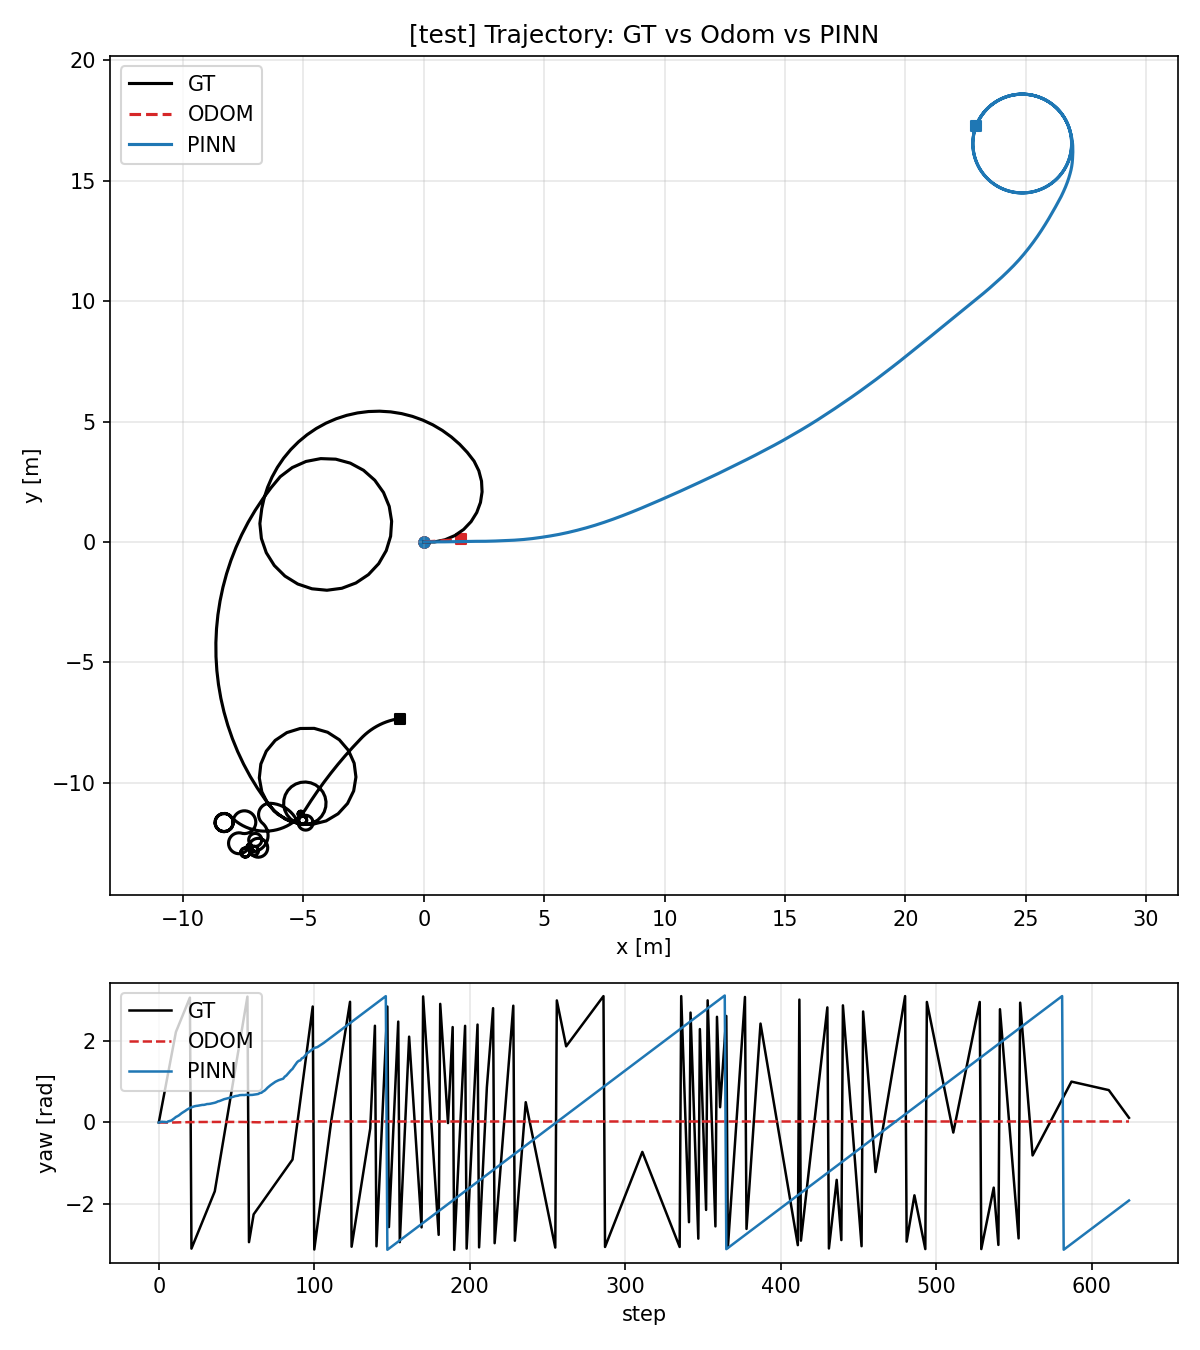

Error over time:


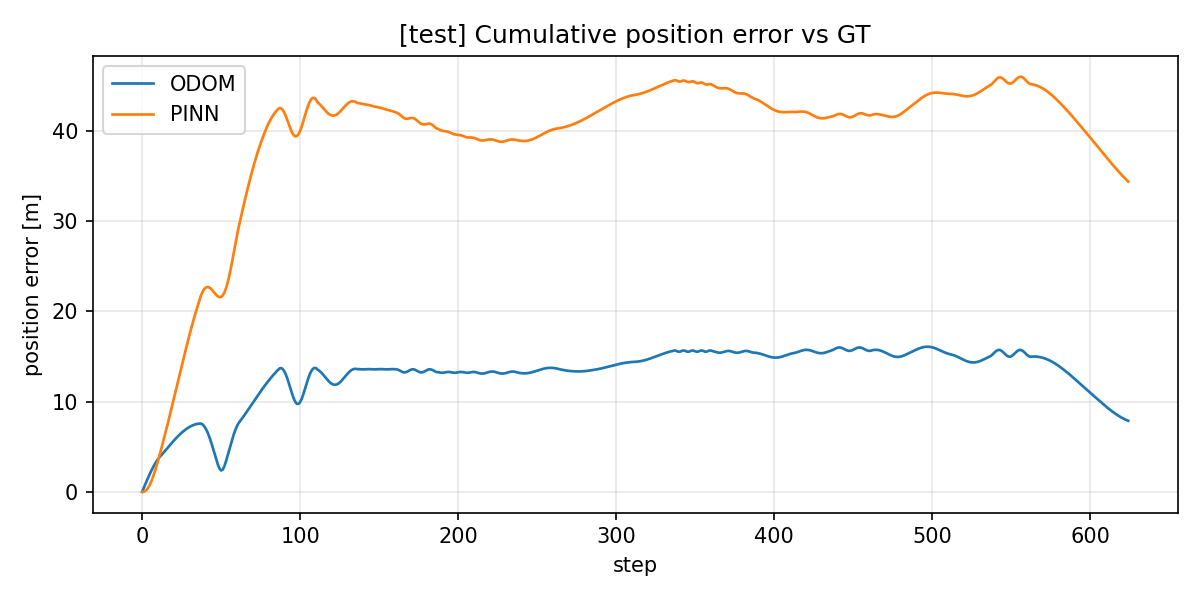

In [32]:
from IPython.display import Image, display
print('Trajectory plot:')
display(Image(filename=metrics['plots']['trajectory']))
print('Error over time:')
display(Image(filename=metrics['plots']['error_over_time']))

## Cell 11 (optional): Ablation runs

Re-train the model with one physics term disabled at a time (`w_nonholonomic=0`,
`w_stationary=0`, `w_coeff=0`). Evaluate each and compare to the full model.
Disabled by default — uncomment to run (adds ~3× training time).

In [ ]:
# ABLATE = False
# if ABLATE:
#     ablation_runs = {
#         'no_nh':    {'w_nonholonomic': 0.0},
#         'no_stat':  {'w_stationary':   0.0},
#         'no_coeff': {'w_coeff':        0.0},
#     }
#     ablation_metrics = {}
#     for tag, overrides in ablation_runs.items():
#         loss_cfg = {'w_data': 1.0, 'w_stationary': 1.0, 'w_nonholonomic': 0.1,
#                     'w_coeff': 0.01, 'w_magnitude': 1e-3,
#                     'data_weights': (w_x, w_yaw)}
#         loss_cfg.update(overrides)
#         ab_model = build_model({'name': 'pinn',
#                                 'model': {'hidden_dim': 128, 'hidden_blocks': 3, 'dropout': 0.1}})
#         ab_loss = build_loss({'loss': loss_cfg})
#         ab_dir = f'{SAVE_DIR}_ablation_{tag}'
#         ab_cfg = TrainConfig(epochs=150, early_stop_patience=15, run_name=f'pinn_{tag}',
#                              seed=42, device='auto', amp=True, log_every=25)
#         ab_res = train_api(ab_model, ab_loss, loaders['train'], loaders['val'], ab_cfg, save_dir=ab_dir)
#         load_best(ab_model, ab_res['best_path'])
#         ab_model = ab_model.to(device).eval()
#         out = run_full_evaluation(ab_model, loaders['test'], save_dir=ab_dir,
#                                   history=ab_res['history'],
#                                   final_coeffs=ab_model.coefficient_values(),
#                                   device='cuda' if torch.cuda.is_available() else 'cpu', tag=tag)
#         ablation_metrics[tag] = out['metrics']
#         print(f'[ablation:{tag}] ATE={out["metrics"]["trajectory"]["pinn_vs_gt"]["ATE_RMSE"]:.4e}')
#     import json as _json
#     print(_json.dumps({k: v['trajectory']['pinn_vs_gt'] for k, v in ablation_metrics.items()}, indent=2))

In [33]:
# ============================================================
# Full-route visualization (OLD STYLE XY MAP)
# - GT / ODOM은 예전 코드처럼 dx, dy를 직접 cumsum
# - PINN은 현재 모델 출력이 d_x_corr, d_yaw_corr 뿐이므로
#   시각화용으로 dy는 odom의 od_d_y를 그대로 사용
# - 즉, PINN XY는 "corrected dx + original odom dy" 누적
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from data_module import load_and_align, INPUT_COLS

# ------------------------------------------------------------
# 0) 체크
# ------------------------------------------------------------
assert 'best_model' in globals(), "best_model not found"
assert 'device' in globals(), "device not found"
assert 'scaler' in globals(), "scaler not found"
assert 'GT_PATH' in globals() and 'ODOM_PATH' in globals(), "GT_PATH / ODOM_PATH not found"
assert 'SAVE_DIR' in globals(), "SAVE_DIR not found"

best_model.eval()

# ------------------------------------------------------------
# 1) 전체 CSV 다시 align
# ------------------------------------------------------------
full_df = load_and_align(GT_PATH, ODOM_PATH, method='nearest').copy()
print(f"[full-route] aligned rows = {len(full_df)}")

print("\n[columns]")
print(full_df.columns.tolist())

needed = [
    'gt_d_x', 'gt_d_y', 'gt_d_yaw',
    'od_d_x', 'od_d_y', 'od_d_yaw'
]
missing = [c for c in needed if c not in full_df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# ------------------------------------------------------------
# 2) 전체 구간 PINN 예측
# ------------------------------------------------------------
x_full_raw = full_df[[f'od_{c}' for c in INPUT_COLS]].values.astype(np.float32)
x_full_std = scaler.transform(x_full_raw).astype(np.float32)

with torch.no_grad():
    x_tensor = torch.from_numpy(x_full_std).to(device)
    pred_full = best_model(x_tensor).cpu().numpy()   # (N, 2) = [d_x_corr, d_yaw_corr]

print("pred_full shape:", pred_full.shape)

# ------------------------------------------------------------
# 3) 예전 방식 trajectory 복원 함수
# ------------------------------------------------------------
def reconstruct_xy_from_delta(dx, dy):
    x = np.cumsum(dx)
    y = np.cumsum(dy)
    return x, y

def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))

def accumulate_yaw(dyaw):
    return np.cumsum(dyaw)

# ------------------------------------------------------------
# 4) GT / ODOM / PINN delta 준비
# ------------------------------------------------------------
gt_dx = full_df["gt_d_x"].to_numpy(dtype=np.float64)
gt_dy = full_df["gt_d_y"].to_numpy(dtype=np.float64)
gt_dyaw = full_df["gt_d_yaw"].to_numpy(dtype=np.float64)

od_dx = full_df["od_d_x"].to_numpy(dtype=np.float64)
od_dy = full_df["od_d_y"].to_numpy(dtype=np.float64)
od_dyaw = full_df["od_d_yaw"].to_numpy(dtype=np.float64)

pinn_dx = pred_full[:, 0].astype(np.float64)
pinn_dyaw = pred_full[:, 1].astype(np.float64)

# ------------------------------------------------------------
# 5) PINN용 dy 선택
#    현재 모델은 dy를 예측하지 않으므로 시각화용으로 odom dy 유지
# ------------------------------------------------------------
pinn_dy_vis = od_dy.copy()

# ------------------------------------------------------------
# 6) XY trajectory (예전 코드 스타일)
# ------------------------------------------------------------
gt_x, gt_y = reconstruct_xy_from_delta(gt_dx, gt_dy)
od_x, od_y = reconstruct_xy_from_delta(od_dx, od_dy)
pinn_x, pinn_y = reconstruct_xy_from_delta(pinn_dx, pinn_dy_vis)

# yaw는 참고용
gt_yaw = accumulate_yaw(gt_dyaw)
od_yaw = accumulate_yaw(od_dyaw)
pinn_yaw = accumulate_yaw(pinn_dyaw)

# 길이 통일
n = min(len(gt_x), len(od_x), len(pinn_x))
gt_x, gt_y, gt_yaw = gt_x[:n], gt_y[:n], gt_yaw[:n]
od_x, od_y, od_yaw = od_x[:n], od_y[:n], od_yaw[:n]
pinn_x, pinn_y, pinn_yaw = pinn_x[:n], pinn_y[:n], pinn_yaw[:n]

gt_dx, gt_dy, gt_dyaw = gt_dx[:n], gt_dy[:n], gt_dyaw[:n]
od_dx, od_dy, od_dyaw = od_dx[:n], od_dy[:n], od_dyaw[:n]
pinn_dx, pinn_dyaw = pinn_dx[:n], pinn_dyaw[:n]

# ------------------------------------------------------------
# 7) metric 함수 (예전 코드 스타일 + yaw 보조)
# ------------------------------------------------------------
def step_rmse_xy(ref_dx, ref_dy, est_dx, est_dy):
    err = np.sqrt((est_dx - ref_dx) ** 2 + (est_dy - ref_dy) ** 2)
    return float(np.sqrt(np.mean(err ** 2)))

def trajectory_ate_xy(ref_x, ref_y, est_x, est_y):
    err = np.sqrt((est_x - ref_x) ** 2 + (est_y - ref_y) ** 2)
    return float(np.sqrt(np.mean(err ** 2)))

def trajectory_rte_xy(ref_x, ref_y, est_x, est_y, window=50):
    vals = []
    for i in range(0, len(ref_x) - window):
        ref_seg_x = ref_x[i + window] - ref_x[i]
        ref_seg_y = ref_y[i + window] - ref_y[i]
        est_seg_x = est_x[i + window] - est_x[i]
        est_seg_y = est_y[i + window] - est_y[i]
        vals.append(np.sqrt((est_seg_x - ref_seg_x) ** 2 + (est_seg_y - ref_seg_y) ** 2))
    return float(np.mean(vals)) if len(vals) > 0 else np.nan

def final_position_error(ref_x, ref_y, est_x, est_y):
    return float(np.sqrt((est_x[-1] - ref_x[-1]) ** 2 + (est_y[-1] - ref_y[-1]) ** 2))

def yaw_rmse(ref_yaw, est_yaw):
    return float(np.sqrt(np.mean(wrap_angle(est_yaw - ref_yaw) ** 2)))

# ------------------------------------------------------------
# 8) metrics 계산
# ------------------------------------------------------------
WINDOW = 50

odom_step_rmse_xy = step_rmse_xy(gt_dx, gt_dy, od_dx, od_dy)
pinn_step_rmse_xy = step_rmse_xy(gt_dx, gt_dy, pinn_dx, pinn_dy_vis)

odom_ate = trajectory_ate_xy(gt_x, gt_y, od_x, od_y)
pinn_ate = trajectory_ate_xy(gt_x, gt_y, pinn_x, pinn_y)

odom_rte = trajectory_rte_xy(gt_x, gt_y, od_x, od_y, window=WINDOW)
pinn_rte = trajectory_rte_xy(gt_x, gt_y, pinn_x, pinn_y, window=WINDOW)

odom_final = final_position_error(gt_x, gt_y, od_x, od_y)
pinn_final = final_position_error(gt_x, gt_y, pinn_x, pinn_y)

odom_yaw_rmse = yaw_rmse(gt_yaw, od_yaw)
pinn_yaw_rmse = yaw_rmse(gt_yaw, pinn_yaw)

print("=" * 70)
print("FULL ROUTE VISUALIZATION METRICS (OLD-STYLE XY)")
print("=" * 70)

print("[ODOM vs GT]")
print(f"Step RMSE XY : {odom_step_rmse_xy:.6f} m")
print(f"ATE          : {odom_ate:.6f} m")
print(f"RTE(w={WINDOW}) : {odom_rte:.6f} m")
print(f"Final Err    : {odom_final:.6f} m")
print(f"Yaw RMSE     : {odom_yaw_rmse:.6f} rad")
print()

print("[PINN vs GT]")
print(f"Step RMSE XY : {pinn_step_rmse_xy:.6f} m")
print(f"ATE          : {pinn_ate:.6f} m")
print(f"RTE(w={WINDOW}) : {pinn_rte:.6f} m")
print(f"Final Err    : {pinn_final:.6f} m")
print(f"Yaw RMSE     : {pinn_yaw_rmse:.6f} rad")
print()

print(f"ATE reduction (%) : {100.0 * (odom_ate - pinn_ate) / max(odom_ate, 1e-12):+.2f}")
print(f"FPE reduction (%) : {100.0 * (odom_final - pinn_final) / max(odom_final, 1e-12):+.2f}")

# ------------------------------------------------------------
# 9) 저장
# ------------------------------------------------------------
full_eval_dir = os.path.join(SAVE_DIR, "full_route_eval_oldstyle")
os.makedirs(full_eval_dir, exist_ok=True)

metrics = {
    "odom_vs_gt": {
        "step_rmse_xy": odom_step_rmse_xy,
        "ATE": odom_ate,
        "RTE": odom_rte,
        "FinalErr": odom_final,
        "YawRMSE": odom_yaw_rmse,
    },
    "pinn_vs_gt": {
        "step_rmse_xy": pinn_step_rmse_xy,
        "ATE": pinn_ate,
        "RTE": pinn_rte,
        "FinalErr": pinn_final,
        "YawRMSE": pinn_yaw_rmse,
    },
    "note": {
        "pinn_xy_reconstruction": "PINN uses corrected d_x and original odom d_y for visualization."
    }
}

json_path = os.path.join(full_eval_dir, "metrics_oldstyle_xy.json")
with open(json_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("saved:", json_path)

# ------------------------------------------------------------
# 10) trajectory plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 8))
plt.plot(gt_x, gt_y, label="GT", linewidth=2.5, color="black")
plt.plot(od_x, od_y, label=f"ODOM (ATE={odom_ate:.1f}m)", linewidth=2.2, linestyle="--", color="#1f77b4")
plt.plot(pinn_x, pinn_y, label=f"PINN (ATE={pinn_ate:.1f}m)", linewidth=2.2, linestyle="-", color="#d62728")

plt.scatter([gt_x[0]], [gt_y[0]], c="k", s=100, marker="o", label="Start")
plt.scatter([gt_x[-1]], [gt_y[-1]], c="k", s=100, marker="s", label="GT End")

plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title("Trajectory Comparison: GT vs ODOM vs PINN (Old-Style XY)")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

traj_png = os.path.join(full_eval_dir, "trajectory_oldstyle_xy.png")
plt.savefig(traj_png, dpi=180, bbox_inches="tight")
plt.show()

print("saved:", traj_png)

# ------------------------------------------------------------
# 11) RTE curve
# ------------------------------------------------------------
def rte_curve(ref_x, ref_y, est_x, est_y, window=50):
    vals = []
    idxs = []
    for i in range(0, len(ref_x) - window):
        ref_seg_x = ref_x[i + window] - ref_x[i]
        ref_seg_y = ref_y[i + window] - ref_y[i]
        est_seg_x = est_x[i + window] - est_x[i]
        est_seg_y = est_y[i + window] - est_y[i]
        vals.append(np.sqrt((est_seg_x - ref_seg_x) ** 2 + (est_seg_y - ref_seg_y) ** 2))
        idxs.append(i)
    return np.array(idxs), np.array(vals)

idx_o, rte_o = rte_curve(gt_x, gt_y, od_x, od_y, window=WINDOW)
idx_p, rte_p = rte_curve(gt_x, gt_y, pinn_x, pinn_y, window=WINDOW)

plt.figure(figsize=(10, 4))
plt.plot(idx_o, rte_o, label="ODOM RTE", linewidth=1.8, linestyle="--", color="#1f77b4")
plt.plot(idx_p, rte_p, label="PINN RTE", linewidth=1.8, linestyle="-", color="#d62728")
plt.xlabel(f"Step index (window={WINDOW})")
plt.ylabel("Relative position error (m)")
plt.title("RTE Over Time (Old-Style XY)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

rte_png = os.path.join(full_eval_dir, "rte_oldstyle_xy.png")
plt.savefig(rte_png, dpi=180, bbox_inches="tight")
plt.show()

print("saved:", rte_png)

# ------------------------------------------------------------
# 12) yaw curve
# ------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(gt_yaw, label="GT", linewidth=2.0, color="black")
plt.plot(od_yaw, label="ODOM", linewidth=1.8, linestyle="--", color="#1f77b4")
plt.plot(pinn_yaw, label="PINN", linewidth=1.8, linestyle="-", color="#d62728")
plt.xlabel("step")
plt.ylabel("yaw [rad]")
plt.title("Yaw Over Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

yaw_png = os.path.join(full_eval_dir, "yaw_oldstyle_xy.png")
plt.savefig(yaw_png, dpi=180, bbox_inches="tight")
plt.show()

print("saved:", yaw_png)

[full-route] aligned rows = 4151

[columns]
['t', 'od_d_x', 'od_d_y', 'od_d_z', 'od_d_rolling', 'od_d_pitch', 'od_d_yaw', 'gt_d_x', 'gt_d_y', 'gt_d_z', 'gt_d_rolling', 'gt_d_pitch', 'gt_d_yaw', 'gt_x', 'gt_y', 'gt_z', 'gt_gt_heading']
pred_full shape: (4151, 2)
FULL ROUTE VISUALIZATION METRICS (OLD-STYLE XY)
[ODOM vs GT]
Step RMSE XY : 0.376462 m
ATE          : 715.906819 m
RTE(w=50) : 15.764549 m
Final Err    : 1296.954240 m
Yaw RMSE     : 1.874730 rad

[PINN vs GT]
Step RMSE XY : 0.088674 m
ATE          : 74.924977 m
RTE(w=50) : 2.780601 m
Final Err    : 54.831121 m
Yaw RMSE     : 1.665333 rad

ATE reduction (%) : +89.53
FPE reduction (%) : +95.77
saved: /content/runs/pinn/full_route_eval_oldstyle/metrics_oldstyle_xy.json
saved: /content/runs/pinn/full_route_eval_oldstyle/trajectory_oldstyle_xy.png
saved: /content/runs/pinn/full_route_eval_oldstyle/rte_oldstyle_xy.png
saved: /content/runs/pinn/full_route_eval_oldstyle/yaw_oldstyle_xy.png


In [34]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from data_module import load_and_align, INPUT_COLS


# ============================================================
# 0) settings
# ============================================================
assert 'best_model' in globals()
assert 'device' in globals()
assert 'scaler' in globals()
assert 'GT_PATH' in globals() and 'ODOM_PATH' in globals()
assert 'SAVE_DIR' in globals()

IMU_PATH = "/content/imu.csv"   # 필요하면 경로 수정

best_model.eval()


# ============================================================
# 1) load aligned odom / gt
# ============================================================
full_df = load_and_align(GT_PATH, ODOM_PATH, method="nearest").copy()
print("aligned rows:", len(full_df))
print(full_df.columns.tolist())


# ============================================================
# 2) load original GT absolute xy
# ============================================================
gt_raw = pd.read_csv(GT_PATH)

if not all(c in gt_raw.columns for c in ["t", "x", "y", "z"]):
    raise ValueError("GT csv must contain t, x, y, z")

# full_df 시간 기준으로 GT absolute를 다시 nearest align
gt_abs = pd.merge_asof(
    full_df[["t"]].sort_values("t"),
    gt_raw[["t", "x", "y", "z"]].sort_values("t"),
    on="t",
    direction="nearest"
).dropna().reset_index(drop=True)

gt_x = gt_abs["x"].to_numpy(dtype=np.float64)
gt_y = gt_abs["y"].to_numpy(dtype=np.float64)

# 시작점을 0,0으로 정렬
gt_x = gt_x - gt_x[0]
gt_y = gt_y - gt_y[0]

n = len(gt_x)
full_df = full_df.iloc[:n].reset_index(drop=True)


# ============================================================
# 3) PINN prediction
# ============================================================
x_full_raw = full_df[[f"od_{c}" for c in INPUT_COLS]].values.astype(np.float32)
x_full_std = scaler.transform(x_full_raw).astype(np.float32)

with torch.no_grad():
    x_tensor = torch.from_numpy(x_full_std).to(device)
    pred_full = best_model(x_tensor).cpu().numpy()

pinn_dx = pred_full[:, 0].astype(np.float64)
pinn_dyaw = pred_full[:, 1].astype(np.float64)


# ============================================================
# 4) helper functions
# ============================================================
def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))


def integrate_relative_motion(dx, dy, dyaw):
    """
    body-frame relative motion:
    dx, dy, dyaw -> global x, y, yaw
    """
    dx = np.asarray(dx, dtype=np.float64)
    dy = np.asarray(dy, dtype=np.float64)
    dyaw = np.asarray(dyaw, dtype=np.float64)

    x = np.zeros(len(dx) + 1)
    y = np.zeros(len(dx) + 1)
    yaw = np.zeros(len(dx) + 1)

    for k in range(len(dx)):
        c = np.cos(yaw[k])
        s = np.sin(yaw[k])

        x[k + 1] = x[k] + c * dx[k] - s * dy[k]
        y[k + 1] = y[k] + s * dx[k] + c * dy[k]
        yaw[k + 1] = wrap_angle(yaw[k] + dyaw[k])

    return x, y, yaw


def align_2d(src_x, src_y, tgt_x, tgt_y, use_scale=False):
    """
    source trajectory를 target trajectory에 회전 + 이동 정렬.
    use_scale=True면 scale까지 맞춤.
    """
    src = np.column_stack([src_x, src_y])
    tgt = np.column_stack([tgt_x, tgt_y])

    m = min(len(src), len(tgt))
    src = src[:m]
    tgt = tgt[:m]

    src_mean = src.mean(axis=0)
    tgt_mean = tgt.mean(axis=0)

    src_c = src - src_mean
    tgt_c = tgt - tgt_mean

    H = src_c.T @ tgt_c
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T

    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    if use_scale:
        scale = np.sum(S) / np.sum(src_c ** 2)
    else:
        scale = 1.0

    aligned = scale * src @ R.T + (tgt_mean - scale * src_mean @ R.T)

    return aligned[:, 0], aligned[:, 1]


def trajectory_ate(ref_x, ref_y, est_x, est_y):
    m = min(len(ref_x), len(est_x))
    err = np.sqrt((est_x[:m] - ref_x[:m]) ** 2 + (est_y[:m] - ref_y[:m]) ** 2)
    return float(np.sqrt(np.mean(err ** 2)))


# ============================================================
# 5) ODOM trajectory
# ============================================================
od_dx = full_df["od_d_x"].to_numpy(dtype=np.float64)
od_dy = full_df["od_d_y"].to_numpy(dtype=np.float64)
od_dyaw = full_df["od_d_yaw"].to_numpy(dtype=np.float64)

odom_x, odom_y, odom_yaw = integrate_relative_motion(od_dx, od_dy, od_dyaw)


# ============================================================
# 6) PINN trajectory
#    모델이 dx, dyaw만 예측하므로 dy는 0 또는 odom dy 사용
# ============================================================
pinn_dy = np.zeros_like(pinn_dx)
# 필요하면 아래처럼 바꿀 수 있음:
# pinn_dy = od_dy.copy()

pinn_x, pinn_y, pinn_yaw = integrate_relative_motion(
    pinn_dx,
    pinn_dy,
    pinn_dyaw
)


# ============================================================
# 7) IMU trajectory
# ============================================================
imu_x_aligned = None
imu_y_aligned = None

if os.path.exists(IMU_PATH):
    imu = pd.read_csv(IMU_PATH)

    imu_t = imu["t"].to_numpy(dtype=np.float64)
    imu_dt = imu["dt"].to_numpy(dtype=np.float64)
    imu_ax = imu["ax"].to_numpy(dtype=np.float64)
    imu_ay = imu["ay"].to_numpy(dtype=np.float64)
    imu_wz = imu["wz"].to_numpy(dtype=np.float64)

    imu_x = np.zeros(len(imu))
    imu_y = np.zeros(len(imu))
    imu_vx = np.zeros(len(imu))
    imu_vy = np.zeros(len(imu))
    imu_yaw = np.zeros(len(imu))

    for i in range(1, len(imu)):
        dt = imu_dt[i]
        imu_yaw[i] = wrap_angle(imu_yaw[i - 1] + imu_wz[i] * dt)

        c = np.cos(imu_yaw[i])
        s = np.sin(imu_yaw[i])

        ax_w = c * imu_ax[i] - s * imu_ay[i]
        ay_w = s * imu_ax[i] + c * imu_ay[i]

        imu_vx[i] = imu_vx[i - 1] + ax_w * dt
        imu_vy[i] = imu_vy[i - 1] + ay_w * dt

        imu_x[i] = imu_x[i - 1] + imu_vx[i] * dt
        imu_y[i] = imu_y[i - 1] + imu_vy[i] * dt

    # IMU는 길이가 다르므로 index 기준 resample
    idx_old = np.linspace(0, 1, len(imu_x))
    idx_new = np.linspace(0, 1, len(gt_x))
    imu_x_rs = np.interp(idx_new, idx_old, imu_x)
    imu_y_rs = np.interp(idx_new, idx_old, imu_y)

    imu_x_aligned, imu_y_aligned = align_2d(
        imu_x_rs,
        imu_y_rs,
        gt_x,
        gt_y,
        use_scale=True
    )


# ============================================================
# 8) Align ODOM / PINN to GT frame
# ============================================================
odom_x_aligned, odom_y_aligned = align_2d(
    odom_x,
    odom_y,
    gt_x,
    gt_y,
    use_scale=False
)

pinn_x_aligned, pinn_y_aligned = align_2d(
    pinn_x,
    pinn_y,
    gt_x,
    gt_y,
    use_scale=False
)


# ============================================================
# 9) Metrics
# ============================================================
odom_ate = trajectory_ate(gt_x, gt_y, odom_x_aligned, odom_y_aligned)
pinn_ate = trajectory_ate(gt_x, gt_y, pinn_x_aligned, pinn_y_aligned)

print("ODOM ATE:", odom_ate)
print("PINN ATE:", pinn_ate)

if imu_x_aligned is not None:
    imu_ate = trajectory_ate(gt_x, gt_y, imu_x_aligned, imu_y_aligned)
    print("IMU ATE:", imu_ate)


# ============================================================
# 10) Plot
# ============================================================
plt.figure(figsize=(10, 8))

plt.plot(gt_x, gt_y, color="black", linewidth=2.5, label="GT absolute")
plt.plot(
    odom_x_aligned,
    odom_y_aligned,
    linestyle="--",
    linewidth=2.0,
    label=f"ODOM relative aligned (ATE={odom_ate:.2f}m)"
)
plt.plot(
    pinn_x_aligned,
    pinn_y_aligned,
    linewidth=2.0,
    label=f"PINN relative aligned (ATE={pinn_ate:.2f}m)"
)

if imu_x_aligned is not None:
    plt.plot(
        imu_x_aligned,
        imu_y_aligned,
        linestyle=":",
        linewidth=2.0,
        label=f"IMU integrated aligned (ATE={imu_ate:.2f}m)"
    )

plt.scatter(gt_x[0], gt_y[0], c="k", s=80, marker="o", label="Start")
plt.scatter(gt_x[-1], gt_y[-1], c="k", s=80, marker="s", label="GT End")

plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.title("Trajectory Comparison: GT absolute vs ODOM / PINN / IMU aligned")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out_dir = os.path.join(SAVE_DIR, "full_route_eval_aligned_absolute_gt")
os.makedirs(out_dir, exist_ok=True)

png_path = os.path.join(out_dir, "trajectory_aligned_absolute_gt.png")
plt.savefig(png_path, dpi=180, bbox_inches="tight")
plt.show()

print("saved:", png_path)

aligned rows: 4151
['t', 'od_d_x', 'od_d_y', 'od_d_z', 'od_d_rolling', 'od_d_pitch', 'od_d_yaw', 'gt_d_x', 'gt_d_y', 'gt_d_z', 'gt_d_rolling', 'gt_d_pitch', 'gt_d_yaw', 'gt_x', 'gt_y', 'gt_z', 'gt_gt_heading']
ODOM ATE: 5.4388009584933155
PINN ATE: 104.91835033606444
saved: /content/runs/pinn/full_route_eval_aligned_absolute_gt/trajectory_aligned_absolute_gt.png
